In [ ]:
import yfinance as yf

In [ ]:
data = yf.download('AAPL', start='2008-01-01',end='2024-01-01')

/tmp/ipykernel_4511/2384028636.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2008-01-01',end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df = data[['Close']]

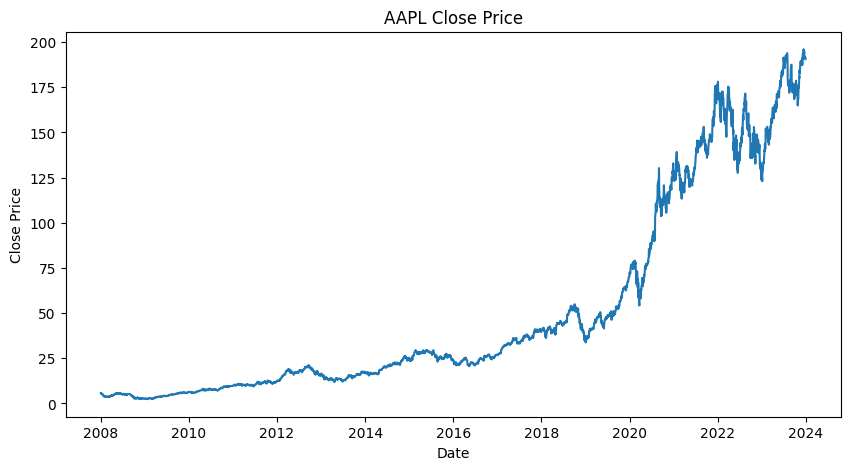

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))
plt.plot(data['Close'])
plt.title('AAPL Close Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

In [ ]:
def create_sequence(df, sequence_length = 60):
  # here i am not using a lag, but we can use a lag later
  in_sequences, targets = [],[]
  for i in range(sequence_length,len(df)):
    in_sequences.append(df.iloc[i-sequence_length:i])
    targets.append(df.iloc[i,:])
  return np.array(in_sequences), np.array(targets)

In [ ]:
in_sequences, targets = create_sequence(df)

In [ ]:
!pip install deeptrack
import deeptrack as dt

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.6/195.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 16.8 MB/s eta 0:00:00
  Created wheel for lazy_import: filename=lazy_import-0.2.2-py2.py3-none-any.whl size=16496 sha256=68e08fc5eea3a56a76b7d2e2be6b892759b2ce336e3d8373391fe96e94b405b6
  Stored in directory: /root/.cache/pip/wheels/53/39/fd/6e74643ad16a5b74e6dff64a2ea3db4c7cb725a8992c55c52d
Successfully built lazy_import


/usr/local/lib/python3.12/dist-packages/deeptrack/__init__.py:14: UserWarning: TensorFlow is detected in your environment. DeepTrack2 version 2.0++ no longer supports TensorFlow. If you need TensorFlow support, please install the legacy version 1.7 of DeepTrack2:

    pip install deeptrack==1.7

For more details, refer to the DeepTrack documentation.
  warnings.warn(


In [ ]:
sources = dt.sources.Source(inputs=in_sequences,targets=targets)

train_sources, val_sources = dt.sources.random_split(sources,[0.8,0.2])

In [ ]:
#nomalization
import torch
train_mean = np.mean([src['inputs'] for src in train_sources], axis=(0,1))
train_std = np.std([src['inputs'] for src in train_sources],axis=(0,1))

inputs_pipeline = (dt.Value(sources.inputs - train_mean)/train_std
                  >> dt.pytorch.ToTensor(dtype=torch.float))
targets_pipeline = (dt.Value(sources.targets - train_mean)/
                    train_std)  >> dt.pytorch.ToTensor(dtype=torch.float)


In [ ]:
from torch.utils.data import DataLoader

train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                   inputs=train_sources)

val_dataset = dt.pytorch.Dataset(inputs_pipeline&targets_pipeline,
                                 inputs=val_sources)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32,shuffle=True)



In [ ]:
!pip install deeplay
import deeplay as dl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.7/176.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 36.1 MB/s eta 0:00:00


In [ ]:
def get_device():
  if torch.cuda.is_available():
    return torch.device('cuda:0')
  elif torch.backends.mps.is_available():
    return torch.device('mps')
  else:
    return torch.device('cpu')

device = get_device()

In [ ]:
import torch.nn as nn

rnn = nn.LSTM(
    input_size=in_sequences.shape[2],
    hidden_size=32,
    batch_first=True
)
fc = nn.Linear(
    in_features=32, out_features=1
)
rnn.to(device);fc.to(device)

Linear(in_features=32, out_features=1, bias=True)

In [ ]:
criterion = nn.L1Loss()
parameter_list = list(rnn.parameters()) + list(fc.parameters())
optimizer = torch.optim.Adam(parameter_list,lr=0.001)

epochs = 100
train_losses, val_losses=[], []
for epoch in range(epochs):
  train_loss =0.0
  for in_sequences, targets in train_loader:
    optimizer.zero_grad()

    in_sequences, targets = in_sequences.to(device), targets.to(device)
    hidden_sequences,_ = rnn(in_sequences)
    last_hidden_states = hidden_sequences[:,-1,:]
    predictions = fc(last_hidden_states)

    loss = criterion(predictions, targets)
    loss.backward()
    optimizer.step()
    train_loss += loss.item()
  train_losses.append(train_loss/len(train_loader))

  val_loss=0.0
  with torch.no_grad():
    for in_sequences, targets in val_loader:
        in_sequences, targets = in_sequences.to(device), targets.to(device)
        hidden_sequences,_ = rnn(in_sequences)
        last_hidden_states = hidden_sequences[:,-1,:]
        predictions = fc(last_hidden_states)

        loss = criterion(predictions, targets)
        val_loss += loss.item()

    val_losses.append(val_loss/len(val_loader))
    print(f'Epoch {epoch} Validation Loss: {val_losses[-1]:.4f}')

Epoch 0 Validation Loss: 0.0617
Epoch 1 Validation Loss: 0.0247
Epoch 2 Validation Loss: 0.0286
Epoch 3 Validation Loss: 0.0205
Epoch 4 Validation Loss: 0.0237
Epoch 5 Validation Loss: 0.0224
Epoch 6 Validation Loss: 0.0199
Epoch 7 Validation Loss: 0.0237
Epoch 8 Validation Loss: 0.0210
Epoch 9 Validation Loss: 0.0178
Epoch 10 Validation Loss: 0.0176
Epoch 11 Validation Loss: 0.0186
Epoch 12 Validation Loss: 0.0196
Epoch 13 Validation Loss: 0.0214
Epoch 14 Validation Loss: 0.0210
Epoch 15 Validation Loss: 0.0173
Epoch 16 Validation Loss: 0.0183
Epoch 17 Validation Loss: 0.0168
Epoch 18 Validation Loss: 0.0177
Epoch 19 Validation Loss: 0.0162
Epoch 20 Validation Loss: 0.0164
Epoch 21 Validation Loss: 0.0162
Epoch 22 Validation Loss: 0.0180
Epoch 23 Validation Loss: 0.0160
Epoch 24 Validation Loss: 0.0216
Epoch 25 Validation Loss: 0.0173
Epoch 26 Validation Loss: 0.0156
Epoch 27 Validation Loss: 0.0151
Epoch 28 Validation Loss: 0.0182
Epoch 29 Validation Loss: 0.0180
Epoch 30 Validation 

In [ ]:
def plot_training(epochs, train_losses, val_losses):
    """Plot the training and validation losses."""
    plt.plot(range(epochs), train_losses, label="Training Loss")
    plt.plot(range(epochs), val_losses, "--", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.xlim([0, epochs - 1])
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

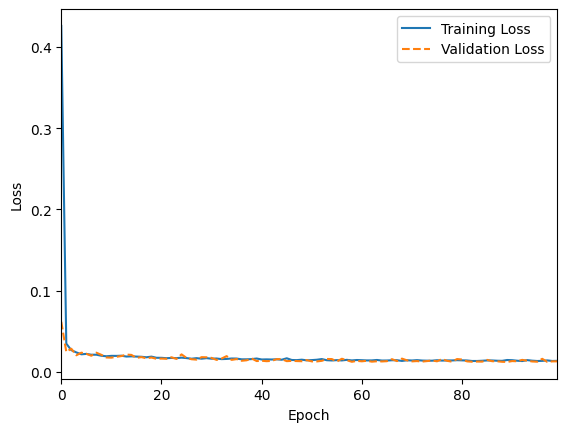

In [ ]:
plot_training(100,train_losses, val_losses)

In [ ]:
rnn_dl = dl.RecurrentModel(
    in_features=in_sequences.shape[2],
    hidden_features=[32],
    out_features=1,
    rnn_type='LSTM',
)

rnn_simple = dl.Regressor(rnn_dl,optimizer=dl.Adam(lr=0.001)).create()

In [ ]:
trainer = dl.Trainer(max_epochs=100, accelerator='auto')
trainer.fit(rnn_simple, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss           │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ RecurrentModel   │  4.5 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 4.5 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 4.5 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

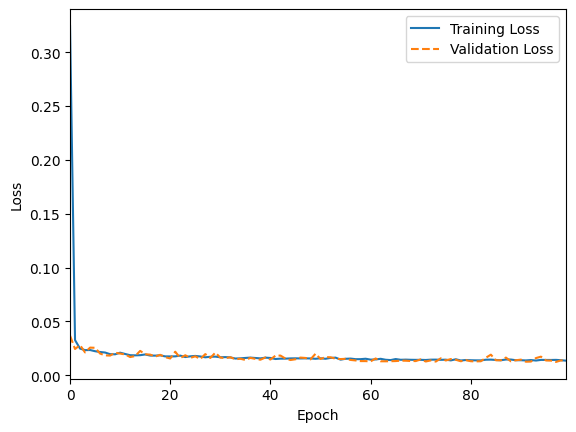

In [ ]:
train_losses = trainer.history.history['train_loss_epoch']['value']
val_losses = trainer.history.history['val_loss_epoch']['value'][1:]
plot_training(100,train_losses,val_losses)


In [ ]:
import nbformat
nb = nbformat.read("notebook.ipynb", as_version=nbformat.NO_CONVERT)
if "widgets" in nb.metadata and "state" not in nb.metadata.widgets:
  nb.metadata["widgets"] = {"state": {}}
nbformat.write(nb, "notebook_fixed.ipynb")
